In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Identifica a raiz do projeto.
# Se o notebook estiver sendo executado dentro da pasta notebooks/, a raiz fica um nível acima.
CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name == "notebooks":
    PROJECT_DIR = CURRENT_DIR.parent
else:
    PROJECT_DIR = CURRENT_DIR

# Caso o VS Code execute o notebook em outro diretório, tenta localizar a raiz pelo caminho relativo.
if not (PROJECT_DIR / "data").exists() and (Path("..") / "data").exists():
    PROJECT_DIR = Path("..").resolve()

TRAIN_CSV = PROJECT_DIR / "data" / "raw" / "train.csv"
TRAIN_IMAGES_DIR = PROJECT_DIR / "data" / "raw" / "train_images"

print("Raiz do projeto:", PROJECT_DIR)
print("Arquivo train.csv:", TRAIN_CSV)
print("Pasta train_images:", TRAIN_IMAGES_DIR)

if not TRAIN_CSV.exists():
    raise FileNotFoundError(f"Arquivo não encontrado: {TRAIN_CSV}")

if not TRAIN_IMAGES_DIR.exists():
    raise FileNotFoundError(f"Pasta não encontrada: {TRAIN_IMAGES_DIR}")

df = pd.read_csv(TRAIN_CSV)

df.head()


Raiz do projeto: g:\caio\tcc-retinopatia-diabetica
Arquivo train.csv: g:\caio\tcc-retinopatia-diabetica\data\raw\train.csv
Pasta train_images: g:\caio\tcc-retinopatia-diabetica\data\raw\train_images


,id_code,diagnosis
0,000c1434d8d7,2
1,001639a390f0,4
2,0024cdab0c1e,1
3,002c21358ce6,0
4,005b95c28852,0


In [2]:
# Informações gerais do dataframe
print(df.info())

# Quantidade de linhas e colunas
print("Dimensão do train.csv:", df.shape)

# Conferir nomes das colunas
print("Colunas:", df.columns.tolist())

<class 'pandas.DataFrame'>
RangeIndex: 3662 entries, 0 to 3661
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   id_code    3662 non-null   str  
 1   diagnosis  3662 non-null   int64
dtypes: int64(1), str(1)
memory usage: 57.3 KB
None
Dimensão do train.csv: (3662, 2)
Colunas: ['id_code', 'diagnosis']


In [3]:
class_names = {
    0: "Sem retinopatia",
    1: "Retinopatia leve",
    2: "Retinopatia moderada",
    3: "Retinopatia severa",
    4: "Retinopatia proliferativa"
}

df["diagnosis_name"] = df["diagnosis"].map(class_names)

df.head()

,id_code,diagnosis,diagnosis_name
0,000c1434d8d7,2,Retinopatia moderada
1,001639a390f0,4,Retinopatia proliferativa
2,0024cdab0c1e,1,Retinopatia leve
3,002c21358ce6,0,Sem retinopatia
4,005b95c28852,0,Sem retinopatia


In [4]:
class_distribution = (
    df["diagnosis"]
    .value_counts()
    .sort_index()
    .reset_index()
)

class_distribution.columns = ["classe", "quantidade"]
class_distribution["descricao"] = class_distribution["classe"].map(class_names)
class_distribution["percentual"] = (
    class_distribution["quantidade"] / class_distribution["quantidade"].sum() * 100
).round(2)

class_distribution

,classe,quantidade,descricao,percentual
0,0,1805,Sem retinopatia,49.29
1,1,370,Retinopatia leve,10.10
2,2,999,Retinopatia moderada,27.28
3,3,193,Retinopatia severa,5.27
4,4,295,Retinopatia proliferativa,8.06


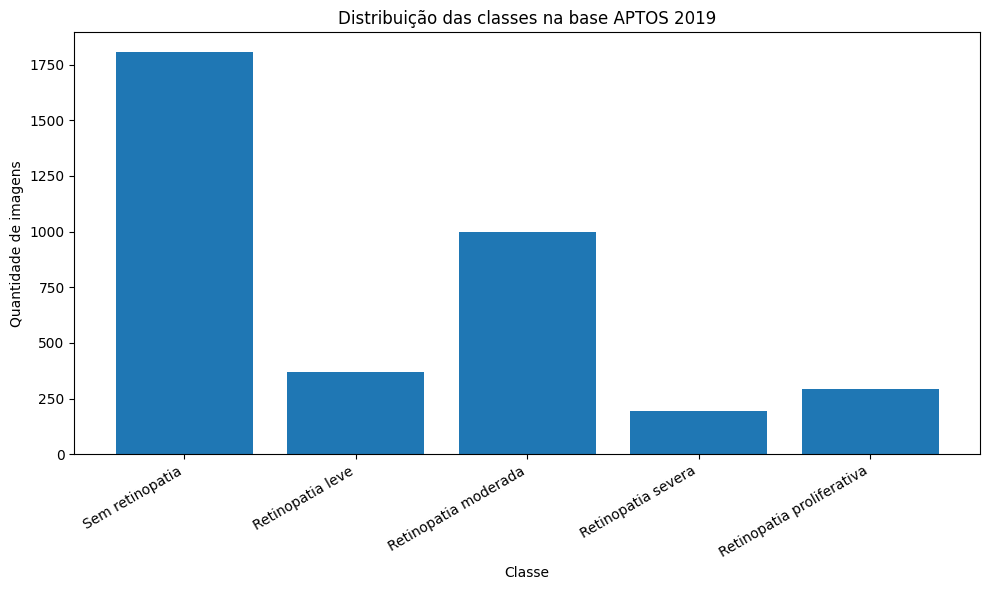

In [5]:
plt.figure(figsize=(10, 6))

plt.bar(
    class_distribution["descricao"],
    class_distribution["quantidade"]
)

plt.title("Distribuição das classes na base APTOS 2019")
plt.xlabel("Classe")
plt.ylabel("Quantidade de imagens")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

plt.show()

In [6]:
df["image_path"] = df["id_code"].apply(
    lambda x: TRAIN_IMAGES_DIR / f"{x}.png"
)

df["image_exists"] = df["image_path"].apply(lambda x: x.exists())

total_images_csv = len(df)
existing_images = int(df["image_exists"].sum())
missing_images = total_images_csv - existing_images

print("Total de registros no train.csv:", total_images_csv)
print("Imagens encontradas:", existing_images)
print("Imagens ausentes:", missing_images)

if missing_images > 0:
    print("\nAtenção: existem imagens listadas no train.csv que não foram encontradas na pasta train_images.")
    print("Verifique se a base APTOS foi copiada ou extraída completamente.")


Total de registros no train.csv: 3662
Imagens encontradas: 3662
Imagens ausentes: 0


In [7]:
df_missing = df[df["image_exists"] == False]

df_missing

,id_code,diagnosis,diagnosis_name,image_path,image_exists


In [8]:
RESULTS_DIR = PROJECT_DIR / "results" / "metrics"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

class_distribution.to_csv(
    RESULTS_DIR / "class_distribution.csv",
    index=False
)

print("Arquivo salvo em:", RESULTS_DIR / "class_distribution.csv")

Arquivo salvo em: g:\caio\tcc-retinopatia-diabetica\results\metrics\class_distribution.csv


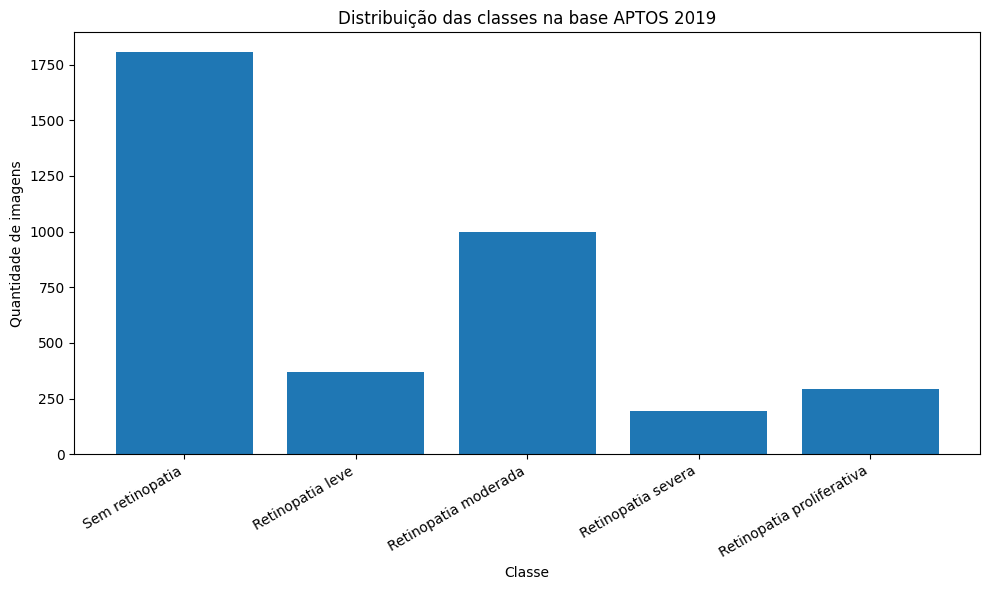

Gráfico salvo em: g:\caio\tcc-retinopatia-diabetica\results\figures\class_distribution.png


In [9]:
FIGURES_DIR = PROJECT_DIR / "results" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(10, 6))

plt.bar(
    class_distribution["descricao"],
    class_distribution["quantidade"]
)

plt.title("Distribuição das classes na base APTOS 2019")
plt.xlabel("Classe")
plt.ylabel("Quantidade de imagens")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

plt.savefig(FIGURES_DIR / "class_distribution.png", dpi=300)
plt.show()

print("Gráfico salvo em:", FIGURES_DIR / "class_distribution.png")

In [10]:
import pandas as pd
from pathlib import Path

# Reutiliza PROJECT_DIR se ele já existir; caso contrário, tenta localizar a raiz do projeto.
try:
    PROJECT_DIR
except NameError:
    CURRENT_DIR = Path.cwd()
    PROJECT_DIR = CURRENT_DIR.parent if CURRENT_DIR.name == "notebooks" else CURRENT_DIR

SPLITS_DIR = PROJECT_DIR / "data" / "splits"

TRAIN_SPLIT = SPLITS_DIR / "train_split.csv"
VAL_SPLIT = SPLITS_DIR / "val_split.csv"
TEST_SPLIT = SPLITS_DIR / "test_split.csv"

for file_path in [TRAIN_SPLIT, VAL_SPLIT, TEST_SPLIT]:
    if not file_path.exists():
        raise FileNotFoundError(
            f"Arquivo não encontrado: {file_path}\n"
            "Execute antes: python src/prepare_splits.py"
        )

train_df = pd.read_csv(TRAIN_SPLIT)
val_df = pd.read_csv(VAL_SPLIT)
test_df = pd.read_csv(TEST_SPLIT)

print("Treino:", train_df.shape)
print("Validação:", val_df.shape)
print("Teste:", test_df.shape)

print("\nDistribuição no treino:")
print(train_df["diagnosis"].value_counts().sort_index())

print("\nDistribuição na validação:")
print(val_df["diagnosis"].value_counts().sort_index())

print("\nDistribuição no teste:")
print(test_df["diagnosis"].value_counts().sort_index())

print("\nPercentual no treino:")
print((train_df["diagnosis"].value_counts(normalize=True).sort_index() * 100).round(2))

print("\nPercentual na validação:")
print((val_df["diagnosis"].value_counts(normalize=True).sort_index() * 100).round(2))

print("\nPercentual no teste:")
print((test_df["diagnosis"].value_counts(normalize=True).sort_index() * 100).round(2))

split_summary = pd.DataFrame({
    "conjunto": ["Treinamento", "Validação", "Teste", "Total"],
    "quantidade": [len(train_df), len(val_df), len(test_df), len(train_df) + len(val_df) + len(test_df)],
    "percentual": [
        round(len(train_df) / (len(train_df) + len(val_df) + len(test_df)) * 100, 2),
        round(len(val_df) / (len(train_df) + len(val_df) + len(test_df)) * 100, 2),
        round(len(test_df) / (len(train_df) + len(val_df) + len(test_df)) * 100, 2),
        100.00
    ]
})

split_summary


Treino: (2197, 3)
Validação: (732, 3)
Teste: (733, 3)

Distribuição no treino:
diagnosis
0    1083
1     222
2     599
3     116
4     177
Name: count, dtype: int64

Distribuição na validação:
diagnosis
0    361
1     74
2    200
3     38
4     59
Name: count, dtype: int64

Distribuição no teste:
diagnosis
0    361
1     74
2    200
3     39
4     59
Name: count, dtype: int64

Percentual no treino:
diagnosis
0    49.29
1    10.10
2    27.26
3     5.28
4     8.06
Name: proportion, dtype: float64

Percentual na validação:
diagnosis
0    49.32
1    10.11
2    27.32
3     5.19
4     8.06
Name: proportion, dtype: float64

Percentual no teste:
diagnosis
0    49.25
1    10.10
2    27.29
3     5.32
4     8.05
Name: proportion, dtype: float64


,conjunto,quantidade,percentual
0,Treinamento,2197,59.99
1,Validação,732,19.99
2,Teste,733,20.02
3,Total,3662,100.00


In [11]:
RESULTS_DIR = PROJECT_DIR / "results" / "metrics"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

split_summary.to_csv(
    RESULTS_DIR / "split_summary.csv",
    index=False
)

split_class_distribution = pd.concat(
    [
        train_df.assign(conjunto="Treinamento"),
        val_df.assign(conjunto="Validação"),
        test_df.assign(conjunto="Teste")
    ],
    ignore_index=True
)

split_class_distribution = (
    split_class_distribution
    .groupby(["conjunto", "diagnosis"])
    .size()
    .reset_index(name="quantidade")
)

split_class_distribution["descricao"] = split_class_distribution["diagnosis"].map(class_names)

split_class_distribution["percentual_no_conjunto"] = (
    split_class_distribution["quantidade"] /
    split_class_distribution.groupby("conjunto")["quantidade"].transform("sum") *
    100
).round(2)

split_class_distribution.to_csv(
    RESULTS_DIR / "split_class_distribution.csv",
    index=False
)

print("Resumo da divisão salvo em:", RESULTS_DIR / "split_summary.csv")
print("Distribuição por classe em cada subconjunto salva em:", RESULTS_DIR / "split_class_distribution.csv")

split_class_distribution


Resumo da divisão salvo em: g:\caio\tcc-retinopatia-diabetica\results\metrics\split_summary.csv
Distribuição por classe em cada subconjunto salva em: g:\caio\tcc-retinopatia-diabetica\results\metrics\split_class_distribution.csv


,conjunto,diagnosis,quantidade,descricao,percentual_no_conjunto
0,Teste,0,361,Sem retinopatia,49.25
1,Teste,1,74,Retinopatia leve,10.10
2,Teste,2,200,Retinopatia moderada,27.29
3,Teste,3,39,Retinopatia severa,5.32
4,Teste,4,59,Retinopatia proliferativa,8.05
5,Treinamento,0,1083,Sem retinopatia,49.29
6,Treinamento,1,222,Retinopatia leve,10.10
7,Treinamento,2,599,Retinopatia moderada,27.26
8,Treinamento,3,116,Retinopatia severa,5.28
9,Treinamento,4,177,Retinopatia proliferativa,8.06
